In [2]:
# import required libraries
import pandas as pd
import numpy as np
import plotly.graph_objects as go

In [2]:
# import datasets
progress_data = pd.read_excel('KPEIR_Progress_Report.xlsx')
vacc_data = pd.read_excel('UC_Fac_Vac_Data.xlsx')

progress_data.head()

,UC,Facility,Vaccinator,Reg (till Feb 28),Vac(till Feb 28),Reg(1 Mar-10 Mar),Vac(1 Mar-10 Mar),Reg(11 Mar-20 Mar),Vac(11 Mar-20 Mar),Reg(21 Mar-31 Mar),Vac(21 Mar-31 Mar)
0,Arandu,Civil Dispensary Damail Nisar,vac.abidurrehman.mzamankhan,592.0,6866.0,0.0,0.0,6.0,95.0,13.0,105.0
1,NaN,NaN,vac.tariqzaib.mzaibkhan,766.0,8728.0,0.0,0.0,1.0,0.0,16.0,0.0
2,NaN,Rural Health Center Arando,vac.shabnumbibi.muazamkhan,732.0,8616.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Ashirate,"BHU Nagar, Ashrat",vac.badiurrehman.saifullahjan,811.0,9147.0,18.0,190.0,1.0,27.0,8.0,67.0
4,NaN,NaN,vac.irfanullah.zafarullah,544.0,6257.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# vacc data
vacc_data.head()

,UnionCouncilName,Epi_Mis_Facility_Name,VaccinatorName,TotalRegistrations,TotalVaccinations
0,Arandu,Civil Dispensary Damail Nisar,vac.abidurrehman.mzamankhan,0,0
1,Arandu,Civil Dispensary Damail Nisar,vac.tariqzaib.mzaibkhan,0,0
2,Arandu,Rural Health Center Arando,vac.shabnumbibi.muazamkhan,0,0
3,Ashirate,"BHU Nagar, Ashrat",vac.badiurrehman.saifullahjan,18,190
4,Ashirate,"BHU Nagar, Ashrat",vac.irfanullah.zafarullah,0,0


In [8]:
# check empty rows in progress data
progress_data.shape

(112, 11)

In [9]:
vacc_data.shape

(109, 5)

In [16]:
# find no of empty rows
empty = progress_data.Vaccinator.isnull().sum()
empty

3

In [17]:
# drop vacc empty cells
progress_data = progress_data.dropna(subset=['Vaccinator'])
progress_data.shape

(109, 11)

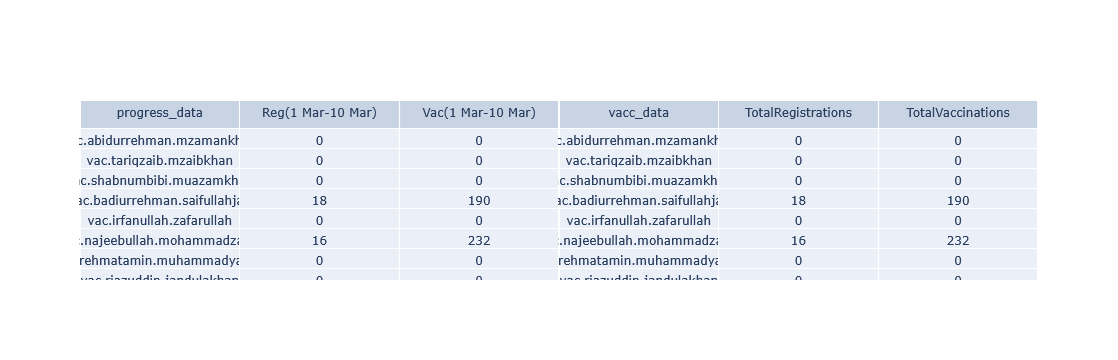

In [24]:
# compare name of vaccinators in 
table = go.Figure(data = [go.Table(
    header = dict(values = ['progress_data','Reg(1 Mar-10 Mar)', 'Vac(1 Mar-10 Mar)', 'vacc_data', 'TotalRegistrations', 'TotalVaccinations']),
    cells = dict(values = [progress_data['Vaccinator'], progress_data['Reg(1 Mar-10 Mar)'], progress_data['Vac(1 Mar-10 Mar)'], vacc_data['VaccinatorName'], vacc_data['TotalRegistrations'], vacc_data['TotalVaccinations']])
)
])
table.show()

In [5]:
# read all the datasets
data1 = pd.read_excel('UC_Fac_Vac_Data1.xlsx')
data2 = pd.read_excel('UC_Fac_Vac_Data2.xlsx')
data3 = pd.read_excel('UC_Fac_Vac_Data3.xlsx')
data4 = pd.read_excel('UC_Fac_Vac_Data4.xlsx')
data5 = pd.read_excel('UC_Fac_Vac_Data5.xlsx')

In [7]:
# now compare vaccinator's name column
comparison_data = pd.concat([
    data1.VaccinatorName.rename('Vacc1'),
    data2.VaccinatorName.rename('Vacc2'),
    data3.VaccinatorName.rename('Vacc3'),
    data4.VaccinatorName.rename('Vacc4'),
    data5.VaccinatorName.rename('Vacc5')
], axis = 1)

comparison_data

,Vacc1,Vacc2,Vacc3,Vacc4,Vacc5
0,vac.abidurrehman.mzamankhan,vac.abidurrehman.mzamankhan,vac.abidurrehman.mzamankhan,vac.abidurrehman.mzamankhan,vac.abidurrehman.mzamankhan
1,vac.tariqzaib.mzaibkhan,vac.tariqzaib.mzaibkhan,vac.tariqzaib.mzaibkhan,vac.tariqzaib.mzaibkhan,vac.tariqzaib.mzaibkhan
2,vac.shabnumbibi.muazamkhan,vac.shabnumbibi.muazamkhan,vac.shabnumbibi.muazamkhan,vac.shabnumbibi.muazamkhan,vac.shabnumbibi.muazamkhan
3,vac.badiurrehman.saifullahjan,vac.badiurrehman.saifullahjan,vac.badiurrehman.saifullahjan,vac.badiurrehman.saifullahjan,vac.badiurrehman.saifullahjan
4,vac.irfanullah.zafarullah,vac.irfanullah.zafarullah,vac.irfanullah.zafarullah,vac.irfanullah.zafarullah,vac.irfanullah.zafarullah
...,...,...,...,...,...
104,vac.husunara.snazirshah,vac.husunara.snazirshah,vac.husunara.snazirshah,vac.husunara.snazirshah,vac.husunara.snazirshah
105,vac.khalidanasab.syednasabh,vac.khalidanasab.syednasabh,vac.khalidanasab.syednasabh,vac.khalidanasab.syednasabh,vac.khalidanasab.syednasabh
106,vac.nafasbibi.msahibkhan,vac.nafasbibi.msahibkhan,vac.nafasbibi.msahibkhan,vac.nafasbibi.msahibkhan,vac.nafasbibi.msahibkhan
107,vac.bushratabasum.saltanatjan,vac.bushratabasum.saltanatjan,vac.bushratabasum.saltanatjan,vac.bushratabasum.saltanatjan,vac.bushratabasum.saltanatjan


In [8]:
# compare
comparison_data['compare'] = comparison_data.nunique(axis = 1) == 1

In [10]:
comparison_data['compare'].value_counts()

compare
True    109
Name: count, dtype: int64

In [11]:
# rename some columns
data1.head()

,UnionCouncilName,Epi_Mis_Facility_Name,VaccinatorName,TotalRegistrations,TotalVaccinations
0,Arandu,Civil Dispensary Damail Nisar,vac.abidurrehman.mzamankhan,0,0
1,Arandu,Civil Dispensary Damail Nisar,vac.tariqzaib.mzaibkhan,0,0
2,Arandu,Rural Health Center Arando,vac.shabnumbibi.muazamkhan,0,0
3,Ashirate,"BHU Nagar, Ashrat",vac.badiurrehman.saifullahjan,18,190
4,Ashirate,"BHU Nagar, Ashrat",vac.irfanullah.zafarullah,0,0


In [12]:
# copy dataset
dataset = data1.copy()

In [13]:
dataset.head()

,UnionCouncilName,Epi_Mis_Facility_Name,VaccinatorName,TotalRegistrations,TotalVaccinations
0,Arandu,Civil Dispensary Damail Nisar,vac.abidurrehman.mzamankhan,0,0
1,Arandu,Civil Dispensary Damail Nisar,vac.tariqzaib.mzaibkhan,0,0
2,Arandu,Rural Health Center Arando,vac.shabnumbibi.muazamkhan,0,0
3,Ashirate,"BHU Nagar, Ashrat",vac.badiurrehman.saifullahjan,18,190
4,Ashirate,"BHU Nagar, Ashrat",vac.irfanullah.zafarullah,0,0


In [14]:
# rename columns
dataset[['Reg(1 Mar-10 Mar)', 'Vac(1 Mar-10 Mar)']] = dataset[['TotalRegistrations', 'TotalVaccinations']]

dataset.head()

,UnionCouncilName,Epi_Mis_Facility_Name,VaccinatorName,TotalRegistrations,TotalVaccinations,Reg(1 Mar-10 Mar),Vac(1 Mar-10 Mar)
0,Arandu,Civil Dispensary Damail Nisar,vac.abidurrehman.mzamankhan,0,0,0,0
1,Arandu,Civil Dispensary Damail Nisar,vac.tariqzaib.mzaibkhan,0,0,0,0
2,Arandu,Rural Health Center Arando,vac.shabnumbibi.muazamkhan,0,0,0,0
3,Ashirate,"BHU Nagar, Ashrat",vac.badiurrehman.saifullahjan,18,190,18,190
4,Ashirate,"BHU Nagar, Ashrat",vac.irfanullah.zafarullah,0,0,0,0


In [15]:
dataset[['Reg(11 Mar-20 Mar)', 'Vac(11 Mar-20 Mar)']] = data2[['TotalRegistrations', 'TotalVaccinations']]

In [16]:
dataset.head()

,UnionCouncilName,Epi_Mis_Facility_Name,VaccinatorName,TotalRegistrations,TotalVaccinations,Reg(1 Mar-10 Mar),Vac(1 Mar-10 Mar),Reg(11 Mar-20 Mar),Vac(11 Mar-20 Mar)
0,Arandu,Civil Dispensary Damail Nisar,vac.abidurrehman.mzamankhan,0,0,0,0,6,95
1,Arandu,Civil Dispensary Damail Nisar,vac.tariqzaib.mzaibkhan,0,0,0,0,1,0
2,Arandu,Rural Health Center Arando,vac.shabnumbibi.muazamkhan,0,0,0,0,0,0
3,Ashirate,"BHU Nagar, Ashrat",vac.badiurrehman.saifullahjan,18,190,18,190,1,27
4,Ashirate,"BHU Nagar, Ashrat",vac.irfanullah.zafarullah,0,0,0,0,0,0


In [17]:
dataset[['Reg(21 Mar-31 Mar)', 'Vac(21 Mar-31 Mar)']] = data3[['TotalRegistrations', 'TotalVaccinations']]

In [18]:
dataset.head()

,UnionCouncilName,Epi_Mis_Facility_Name,VaccinatorName,TotalRegistrations,TotalVaccinations,Reg(1 Mar-10 Mar),Vac(1 Mar-10 Mar),Reg(11 Mar-20 Mar),Vac(11 Mar-20 Mar),Reg(21 Mar-31 Mar),Vac(21 Mar-31 Mar)
0,Arandu,Civil Dispensary Damail Nisar,vac.abidurrehman.mzamankhan,0,0,0,0,6,95,13,105
1,Arandu,Civil Dispensary Damail Nisar,vac.tariqzaib.mzaibkhan,0,0,0,0,1,0,16,0
2,Arandu,Rural Health Center Arando,vac.shabnumbibi.muazamkhan,0,0,0,0,0,0,0,0
3,Ashirate,"BHU Nagar, Ashrat",vac.badiurrehman.saifullahjan,18,190,18,190,1,27,8,67
4,Ashirate,"BHU Nagar, Ashrat",vac.irfanullah.zafarullah,0,0,0,0,0,0,0,0


In [19]:
dataset[['Reg(01 Apr-10 Apr)', 'Vac(01 Apr-10 Apr)']] = data4[['TotalRegistrations', 'TotalVaccinations']]

In [20]:
dataset.head()

,UnionCouncilName,Epi_Mis_Facility_Name,VaccinatorName,TotalRegistrations,TotalVaccinations,Reg(1 Mar-10 Mar),Vac(1 Mar-10 Mar),Reg(11 Mar-20 Mar),Vac(11 Mar-20 Mar),Reg(21 Mar-31 Mar),Vac(21 Mar-31 Mar),Reg(01 Apr-10 Apr),Vac(01 Apr-10 Apr)
0,Arandu,Civil Dispensary Damail Nisar,vac.abidurrehman.mzamankhan,0,0,0,0,6,95,13,105,0,0
1,Arandu,Civil Dispensary Damail Nisar,vac.tariqzaib.mzaibkhan,0,0,0,0,1,0,16,0,0,0
2,Arandu,Rural Health Center Arando,vac.shabnumbibi.muazamkhan,0,0,0,0,0,0,0,0,0,0
3,Ashirate,"BHU Nagar, Ashrat",vac.badiurrehman.saifullahjan,18,190,18,190,1,27,8,67,3,1
4,Ashirate,"BHU Nagar, Ashrat",vac.irfanullah.zafarullah,0,0,0,0,0,0,0,0,0,0


In [21]:
dataset[['Reg(11 Apr-20 Apr)', 'Vac(11 Apr-20 Apr)']] = data5[['TotalRegistrations', 'TotalVaccinations']]

In [22]:
dataset.head()

,UnionCouncilName,Epi_Mis_Facility_Name,VaccinatorName,TotalRegistrations,TotalVaccinations,Reg(1 Mar-10 Mar),Vac(1 Mar-10 Mar),Reg(11 Mar-20 Mar),Vac(11 Mar-20 Mar),Reg(21 Mar-31 Mar),Vac(21 Mar-31 Mar),Reg(01 Apr-10 Apr),Vac(01 Apr-10 Apr),Reg(11 Apr-20 Apr),Vac(11 Apr-20 Apr)
0,Arandu,Civil Dispensary Damail Nisar,vac.abidurrehman.mzamankhan,0,0,0,0,6,95,13,105,0,0,13,158
1,Arandu,Civil Dispensary Damail Nisar,vac.tariqzaib.mzaibkhan,0,0,0,0,1,0,16,0,0,0,0,0
2,Arandu,Rural Health Center Arando,vac.shabnumbibi.muazamkhan,0,0,0,0,0,0,0,0,0,0,0,0
3,Ashirate,"BHU Nagar, Ashrat",vac.badiurrehman.saifullahjan,18,190,18,190,1,27,8,67,3,1,4,109
4,Ashirate,"BHU Nagar, Ashrat",vac.irfanullah.zafarullah,0,0,0,0,0,0,0,0,0,0,0,0


In [23]:
# drop two columns
dataset = dataset.drop(['TotalRegistrations', 'TotalVaccinations'], axis = 1)
dataset.head()

,UnionCouncilName,Epi_Mis_Facility_Name,VaccinatorName,Reg(1 Mar-10 Mar),Vac(1 Mar-10 Mar),Reg(11 Mar-20 Mar),Vac(11 Mar-20 Mar),Reg(21 Mar-31 Mar),Vac(21 Mar-31 Mar),Reg(01 Apr-10 Apr),Vac(01 Apr-10 Apr),Reg(11 Apr-20 Apr),Vac(11 Apr-20 Apr)
0,Arandu,Civil Dispensary Damail Nisar,vac.abidurrehman.mzamankhan,0,0,6,95,13,105,0,0,13,158
1,Arandu,Civil Dispensary Damail Nisar,vac.tariqzaib.mzaibkhan,0,0,1,0,16,0,0,0,0,0
2,Arandu,Rural Health Center Arando,vac.shabnumbibi.muazamkhan,0,0,0,0,0,0,0,0,0,0
3,Ashirate,"BHU Nagar, Ashrat",vac.badiurrehman.saifullahjan,18,190,1,27,8,67,3,1,4,109
4,Ashirate,"BHU Nagar, Ashrat",vac.irfanullah.zafarullah,0,0,0,0,0,0,0,0,0,0


In [24]:
# check for any null values
dataset.isnull().sum()

UnionCouncilName         0
Epi_Mis_Facility_Name    0
VaccinatorName           0
Reg(1 Mar-10 Mar)        0
Vac(1 Mar-10 Mar)        0
Reg(11 Mar-20 Mar)       0
Vac(11 Mar-20 Mar)       0
Reg(21 Mar-31 Mar)       0
Vac(21 Mar-31 Mar)       0
Reg(01 Apr-10 Apr)       0
Vac(01 Apr-10 Apr)       0
Reg(11 Apr-20 Apr)       0
Vac(11 Apr-20 Apr)       0
dtype: int64

In [26]:
# save this file in excel format
dataset.to_excel('progress_data.xlsx', index = False)